# Import & Setup

In [1]:
import os
if os.path.exists('digit_recognizer'):
    !rm -rf digit_recognizer
!git clone https://github.com/Sirius-Siru/digit_recognizer.git

import sys
if '/content/digit_recognizer' not in sys.path:
    sys.path.append('/content/digit_recognizer')

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if os.path.isdir('data') and os.path.exists('data/train.csv'):
    print("✨ Dữ liệu đã sẵn sàng, không cần tải lại.")
else:
    print("🚀 Đang tải dữ liệu...")
    !kaggle competitions download -c digit-recognizer
    !unzip -o digit-recognizer.zip -d data
    !rm -f digit-recognizer.zip

Cloning into 'digit_recognizer'...


remote: Enumerating objects: 220, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 220 (delta 116), reused 170 (delta 67), pack-reused 0 (from 0)
Receiving objects: 100% (220/220), 1.22 MiB | 6.67 MiB/s, done.
Resolving deltas: 100% (116/116), done.
🚀 Đang tải dữ liệu...
100% 15.3M/15.3M [00:01<00:00, 9.30MB/s]

Archive:  digit-recognizer.zip
  inflating: data/sample_submission.csv  
  inflating: data/test.csv           
  inflating: data/train.csv          


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import src.preprocessing as pp

import gc
from joblib import Parallel, delayed

# Load data

In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

X = train.drop('label', axis=1)
y = train['label']

# Unflatten & Normalize
train_img = X.values.reshape(-1, 28, 28) / 255.0
test_img = test.values.reshape(-1, 28, 28) / 255.0

# Preprocessing

In [4]:
from tensorflow.keras.utils import to_categorical

X = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in train_img)
test = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in test_img)

X = np.array(X)
test = np.array(test)

y = to_categorical(y, num_classes=10)

del train_img, test_img
gc.collect()

54

# Setup model

In [ ]:
import tensorflow as tf

def to_3_channel(img):
    # img: (28, 28, 1), giá trị [0,1]

    # channel 1: original
    c1 = img

    # channel 2: edge (Sobel)
    edge = tf.image.sobel_edges(img)        # (28,28,1,2)
    edge = tf.reduce_mean(edge, axis=-1)    # (28,28,1)
    edge = tf.abs(edge)

    # channel 3: dilation (làm đậm nét)
    kernel = tf.ones((3, 3, 1))
    c3 = tf.nn.dilation2d(
        img,
        filters=kernel,
        strides=[1,1,1,1],
        padding="SAME",
        dilations=[1,1,1,1]
    )

    # ghép lại → (28,28,3)
    return tf.concat([c1, edge, c3], axis=-1)   

In [ ]:
X = X.map(lambda x, y: (to_3_channel(x), y))
test   = test.map(lambda x, y: (to_3_channel(x), y))

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Activation

def random_morphology(image):
    # Tạo số ngẫu nhiên để chọn 1 trong 3 trạng thái
    prob = tf.random.uniform([], 0, 1)
    
    # 1. Làm mỏng nét (Erosion) - dùng Min Pooling logic
    def erode():
        return -tf.nn.max_pool2d(-image, ksize=3, strides=1, padding='SAME')
    
    # 2. Làm dày nét (Dilation) - dùng Max Pooling
    def dilate():
        return tf.nn.max_pool2d(image, ksize=3, strides=1, padding='SAME')
    
    # Sử dụng tf.case để chọn nhánh xử lý
    return tf.case([
        (prob < 0.33, erode),
        (prob < 0.66, dilate)
    ], default=lambda: image)

data_augmentation = models.Sequential([
  layers.RandomRotation(0.25, input_shape=(28, 28, 3)),
  layers.RandomZoom(0.05),
  layers.RandomTranslation(0.05, 0.05),
  layers.Lambda(lambda x: random_morphology(x)),
  layers.RandomGaussianBlur(0.005),
  layers.GaussianNoise(0.05)
])

model = models.Sequential([
    layers.Input(shape=(28, 28, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Conv2D(32, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

loss = tf.keras.losses.CategoricalCrossentropy()

model.compile(optimizer='adam',
              loss=loss,
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Train-Test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp

def mixup(dataset, alpha=0.2):
    def _mixup(batch1, batch2):
        x1, y1 = batch1
        x2, y2 = batch2

        batch_size = tf.shape(x1)[0]

        # sample lambda từ Beta distribution
        lam = tfp.distributions.Beta(alpha, alpha).sample([batch_size])

        # reshape cho broadcast
        lam_x = tf.reshape(lam, (batch_size, 1, 1, 1))
        lam_y = tf.reshape(lam, (batch_size, 1))

        # mix dữ liệu
        x = lam_x * x1 + (1 - lam_x) * x2
        y = lam_y * y1 + (1 - lam_y) * y2

        return x, y

    # tạo 2 stream khác nhau
    ds2 = dataset.shuffle(10000)

    return tf.data.Dataset.zip((dataset, ds2)).map(
        _mixup, num_parallel_calls=tf.data.AUTOTUNE
    )

In [ ]:
X_train = mixup(X_train, alpha=0.2)
X_train = X_train.prefetch(tf.data.AUTOTUNE)

# Train model

In [7]:
print(type(X))

<class 'numpy.ndarray'>


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_val, y_val), callbacks = [early_stop, reduce_lr])

Epoch 1/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.8934 - loss: 0.8478 - val_accuracy: 0.9733 - val_loss: 0.6274 - learning_rate: 0.0010
Epoch 2/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 94s 180ms/step - accuracy: 0.9619 - loss: 0.6818 - val_accuracy: 0.9843 - val_loss: 0.5891 - learning_rate: 0.0010
Epoch 3/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 95s 181ms/step - accuracy: 0.9716 - loss: 0.6516 - val_accuracy: 0.9858 - val_loss: 0.5776 - learning_rate: 0.0010
Epoch 4/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 146s 189ms/step - accuracy: 0.9743 - loss: 0.6373 - val_accuracy: 0.9887 - val_loss: 0.5658 - learning_rate: 0.0010
Epoch 5/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 136s 179ms/step - accuracy: 0.9799 - loss: 0.6245 - val_accuracy: 0.9882 - val_loss: 0.5699 - learning_rate: 0.0010
Epoch 6/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 142s 179ms/step - accuracy: 0.9800 - loss: 0.6202 - val_accuracy: 0.9900 - val_loss: 0.5600 - learning_rate: 0.0010
Epoch 7/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 99s 189ms/step - accuracy:

Accuracy = 99.39


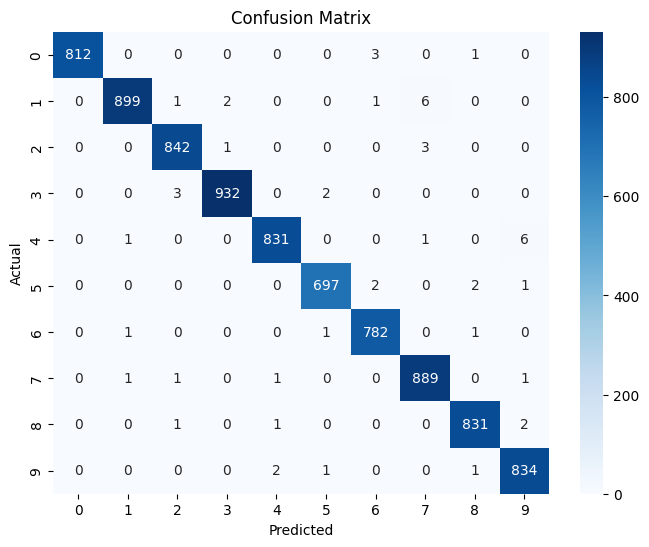

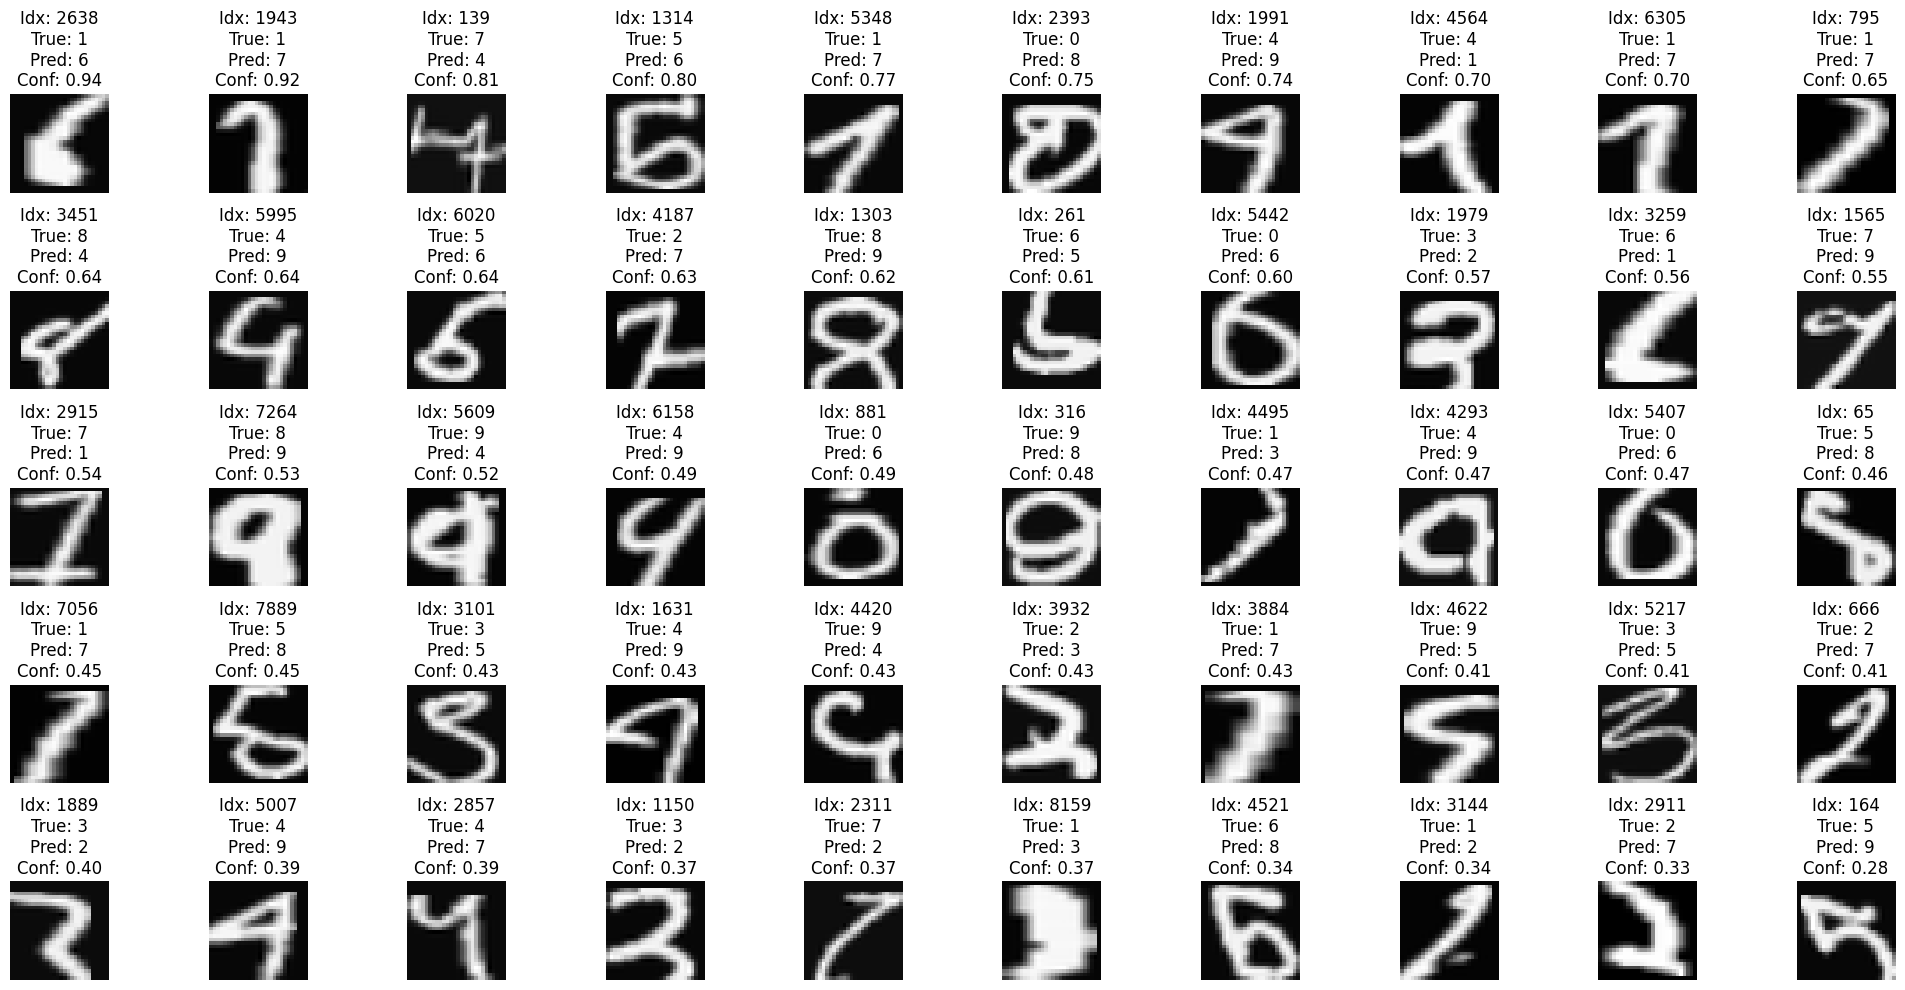

In [23]:
# import src.evaluate as eva
# probs = model.predict(X_val)
# y_pred = np.argmax(probs, axis=1)
eva.evaluate(np.argmax(y_val, axis=1), y_pred)
eva.showWrongCase(model, X_val, pd.DataFrame(np.argmax(y_val, axis=1)).squeeze(), probs) 

# Submission

In [10]:
# model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
#               loss=loss,
#               metrics=['accuracy'])

# model.fit(X, y, epochs=5)
# submission = model.predict(test)

In [11]:
# labels = np.argmax(submission, axis = 1)
# submission = pd.DataFrame(data = labels, columns=['Label'])
# submission.insert(0, 'ImageId', range(1, len(submission)+1))
# submission.to_csv('submission.csv', index = False)

In [12]:
# !kaggle competitions submit -c digit-recognizer -f submission.csv  -m "First submit of the day"